Name: Boondirek Kanjanapongporn

GUID: 2833456k

# Motivation

Model Architecture:

In the coursework, I decided to train the model with many different architectures. In the first few days, I tried training using `MobileNetV2`. I also tried to test abit of `VGG16_U-Net` architecture. Afterwards, I moved on to using `DeepLabV3_ResNet50` and `DeepLabV3_ResNet100` to train the model instead.

My chosen model architecture for this coursework is trained by `eepLabV3ResNet100`

Pre-processing:

1. I created `annotation_to_mask()` function which is to convert the annotation_rgb images into arrays with pixels as class Id.
2. I use `mask_to_rgb_image()` function to convert the arrays into annotation_rgb images to check the correctness
3. Once I know that it is correct, I saved all the arrays and create a folder called `annotation_mask_path` within damages_data folder.
4. I need to also add the path into `metadata.csv` so that it can be loaded to `CustomDataModule`
5. Data Augmentation was also added in some my training experiments to see whether it helps the model generalize better or not. Examples of data augmentation I used includes vertical axis flipping and color jitter (adjusting brightness, hues, saturation), along with random cropping that is provided in the coursework.

Training Process:

I applied quite alot of variation for my training processes for each experiment:

1. Loss: I created `MulticlassDiceLoss` and a `CombinedDiceCross-EntropyLoss` to test on some of my experiments to see how it makes a difference compared to `nn.CrossEntropyLoss()`.
2. Hyper-Parameters: In each of the training experiment, I try to adjust hyper-parameter values as a way to explore the hyper-parameter space, like adjusting the batch size, number of epochs, and learning rate.
3. Mixed Precision Training: Most of my experiments undergo mixed precision training (`GradScaler` and `autocast`) so that we can reduce the training time, memory requirements, and computational power needed to train the model without affecting training performance. This way I can also increase the batch size for training (generally, the larger the batch size the better).
4. Learning Rate Scheduler: LRS is also a good way of dynamically adjusting the global learning rate to not overshoot. Often when we train, during the first few epochs we would want to take a larger step to train faster, and later on taking smaller steps to be more detailed. I utilized `ReduceLROnPlateau()` with a patience of 3 and a reduction of a factor of 0.7.
5. Early Stopping: This is very useful due to the fact that I can stop trainig after I know that the model won't have better performance by training anymore. This can help reduce overfitting and reduce time, since I don't have to wait until the end of the training process every time eventhough the performance is not getting better. I utilized the patience of 10.
6. Saving the Best Model: In each training, I have written a code that would save the best performance trained yet, so that after the training process ends, I know that I have the best possible trained model.
7. Cross-Validation: I try to do cross validation by leaving different class out each time to see which group of classes is best as a training set. However, I had only enough time to cross validate 2 classes.

Result Analysis:

The model performance using `DeepLabV3_ResNet101` come out quite satisfying for the limited time available to do the coursework. In can be noticed that the model does a good job at detecting damages, though the predicted class ID could be wrong. As for predicting class ID, it can be seen that damages of type peel (#FF34FF) and fold (#FFA500) is the easiest to detect among other damages. It can be seen that these two damages are to most frequent identified damages. Following to this is the crack (#0000A6) damage, but it is still not that accurate yet.

Feedback and Limitations:

At the end, I am quite satisfy with the work that I have done. Even though it is not the best, I still think that I have done quite alot and tested quite along under a limited time and pressure of this coursework. I think the main limitation is the GPU RAM available in Google Colab. Even though I used mixed precision training, I think I will still get a better result from having a higher batch size and GPU RAM.

Future Work:

For future work, I can try to test on more architectures to compare the results. I can also try other data augmentations like rotation or mixup augmentation. If have more time, I could do more cross-validation experiments as well.



# Damages - Deep Learning Coursework 2024

The aim of this coursework will be for you to design, implement and test a deep learning architecture to detect and identify damage in images. Digitization allows to make historical pictures and art much more widely available to the public. Many such pictures have suffered some form of damage due to time, storage conditions and the fragility of the original medium. For example, the image below (A) shows an example of a digitized parchment that has suffered significant damage over time.

**The aim of this project is for you to design, implement and evaluate a deep learning model to detect and identify damage present in images.**

<table>
<tr>
<td>
<div>
<img src="damage_data/image_path/cljmrkz5n341f07clcujw105j.png" width="500"/>
</div>
</td>
<td>
<div>
<img src="damage_data/annotation_rgb_path/cljmrkz5n341f07clcujw105j.png" width="500"/>
</div>
</td>
</tr>
<td><center>(A) Image</center></td><td><center>(B) damage labels</center></td>
</table>
*(Note that the images will only show once you have downloaded the dataset)*


The image labels in this figure (B) identifies a smatter of peeling paint, a large stained area in the bottom left and a missing part on the top left. Each colour in those images corresponds to a different category of damage, including `fold`, `writing` or `burn marks`. You are provided with a dataset of a variety of damaged images, from Parchment to ceramic or wood painting, and detailed annotations of a range of damages.

You are free to use any architecture you prefer, from what we have seen in class. You can decide to use unsupervised pre-training of only supervised end-to-end training - the approach you choose is your choice.

### Hand-in date: Friday 15th of March before 4:30pm (on Moodle)

### Steps & Hints
* First, look at the data. What are the different type of images (content), what type of material, what type of damage? How different are they? What type of transformations for your data augmentation do you think would be acceptable here?.
* Second, check the provided helper functions for loading the data and separate into training and test set and cross-validation.
* Design a network for the task. What output? What layers? How many? Do you want to use an Autoencoder for unsupervised pre-training?
* Choose a loss function for your network
* Select optimiser and training parameters (batch size, learning rate)
* Optimise your model, and tune hyperparameters (especially learning rate, momentum etc)
* Analyse the results on the test data. How to measure success? Which classes are recognised well, which are not? Is there confusion between some classes? Look at failure cases.
* If time allows, go back to drawing board and try a more complex, or better, model.
* Explain your thought process, justify your choices and discuss the results!

### Submission
* submit ONE zip file on Moodle containing:
  * **your notebook**: use `File -> download .ipynb` to download the notebook file locally from colab.
  * **a PDF file** of your notebook's output as you see it: use `File -> print` to generate a PDF.
* your notebook must clearly contains separate cells for:
  * setting up your model and data loader
  * training your model from data
  * loading your pretrained model from github/gitlab/any other online storage you like!
  * testing your model on test data.
* The training cells must be disabled by a flag, such that when running *run all* on your notebook it does
  * load the data
  * load your model
  * apply the model to the test data
  * analyse and display the results and accuracy
* In addition provide markup cell:
  * containing your student number at the top
  * to describe and motivate your design choices: architecture, pre-processing, training regime
  * to analyse, describe and comment on your results
  * to provide some discussion on what you think are the limitations of your solution and what could be future work

* **Note that you must put your trained model online so that your code can download it.**


### Assessment criteria
* In order to get a pass mark, you will need to demonstrate that you have designed and trained a deep NN to solve the problem, using sensible approach and reasonable efforts to tune hyper-parameters. You have analysed the results. It is NOT necessary to have any level of accuracy (a network that predicts poorly will always yield a pass mark if it is designed, tuned and analysed sensibly).
* In order to get a good mark, you will show good understanding of the approach and provide a working solution.
* in order to get a high mark, you will demonstrate a working approach of gradual improvement between different versions of your solution.
* bonus marks for attempting something original if well motivated - even if it does not yield increased performance.
* bonus marks for getting high performance, and some more points are to grab for getting the best performance in the class.

### Notes
* You are provided code to isolate the test set and cross validation, make sure to keep the separation clean to ensure proper setting of all hyperparameters.
* I recommend to start with small models that can be easier to train to set a baseline performance before attempting more complex one.
* Be mindful of the time!

## Housekeeping

In [ ]:
!pip install gdown pytorch_lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.6/801.6 kB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.4/840.4 kB 56.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 37.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 50.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 57.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 26.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━

In [2]:


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping
from pytorch_lightning import Trainer

import os
import pandas as pd
import PIL
PIL.Image.MAX_IMAGE_PIXELS = 243748701
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import gdown
import shutil
import random
import sys

DEVICE = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
run_this_cell = False

# Load dataset

We then load the metadata in a dataframe for convenience

In [ ]:
!pwd
!pip install --upgrade --no-cache-dir gdown # Update pip version (default has problems)

/content
  Attempting uninstall: gdown
    Found existing installation: gdown 4.7.3
    Uninstalling gdown-4.7.3:
      Successfully uninstalled gdown-4.7.3


Load zip

In [ ]:
# Original damage data
# !gdown 1kdaB53poIJoqdGAXogVcq35EeYazboe5 -O damages.zip

# Damage data version 2 (with annotation_mask_path v2)
# !gdown 1NkIL7eP1yJYlLe-7TWjy7ZPvf065A8Rv -O damages.zip

# Damage data version 3 (with annotation_mask_path v3)
# !gdown 1JUo4znLkJdDX4lORE-4ni2dKz6KhnLP2 -O damages.zip
# !gdown 1jIBbeVBb58wbPjKF-DvwfiOSTBxnn16v -O damages.zip

# Damage data version 4 (with annotation_mask_path and trained model)
!gdown 1bMwaMKtl15v8c3ildX7xtN3W3dNa0bFP -O damages.zip

Downloading...
From (original): https://drive.google.com/uc?id=1bMwaMKtl15v8c3ildX7xtN3W3dNa0bFP
From (redirected): https://drive.google.com/uc?id=1bMwaMKtl15v8c3ildX7xtN3W3dNa0bFP&confirm=t&uuid=e22b531b-f6b1-405e-bbec-baa7190627cb
To: /content/damages.zip
100% 3.57G/3.57G [00:41<00:00, 85.8MB/s]


Unzip damages.zip file

In [ ]:
import zipfile

# Path to the zip file
zip_path = 'damages.zip'
extraction_path = '/content/'  # This specifies the root directory

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Extracted all contents to {extraction_path}")

Extracted all contents to /content/


In [3]:
# set  that to wherever you want to store the data (eg, your Google Drive), choose a persistent location!
root_dir = '.'
data_dir = os.path.join(root_dir, "damage_data")
csv_path = os.path.join(data_dir, 'metadata.csv')

try:
    df = pd.read_csv(csv_path)

except:  # if the dataset has not been downloaded yet, do it.
    zip_path = os.path.join(root_dir, 'damages.zip')
    gdown.download(id='1JUo4znLkJdDX4lORE-4ni2dKz6KhnLP2', output=zip_path)
    shutil.unpack_archive(zip_path, root_dir)
    df = pd.read_csv(csv_path)

This dataframe has the paths of where the dataset images and annotation labels are stored, plus classification labels.

In [4]:
df

,id,material,content,image_path,annotation_path,annotation_rgb_path,annotation_mask_path
0,cljmrkz5n341f07clcujw105j,Parchment,Artistic depiction,./damage_data/image_path/cljmrkz5n341f07clcujw...,./damage_data/annotation_path/cljmrkz5n341f07c...,./damage_data/annotation_rgb_path/cljmrkz5n341...,./damage_data/annotation_mask_path/cljmrkz5n34...
1,cljmrkz5n341n07clf1u410ed,Parchment,Artistic depiction,./damage_data/image_path/cljmrkz5n341n07clf1u4...,./damage_data/annotation_path/cljmrkz5n341n07c...,./damage_data/annotation_rgb_path/cljmrkz5n341...,./damage_data/annotation_mask_path/cljmrkz5n34...
2,cljmrkz5n341r07clhl93dpre,Parchment,Artistic depiction,./damage_data/image_path/cljmrkz5n341r07clhl93...,./damage_data/annotation_path/cljmrkz5n341r07c...,./damage_data/annotation_rgb_path/cljmrkz5n341...,./damage_data/annotation_mask_path/cljmrkz5n34...
3,cljmrkz5n341v07cl2gfhd6zj,Parchment,Artistic depiction,./damage_data/image_path/cljmrkz5n341v07cl2gfh...,./damage_data/annotation_path/cljmrkz5n341v07c...,./damage_data/annotation_rgb_path/cljmrkz5n341...,./damage_data/annotation_mask_path/cljmrkz5n34...
4,cljmrkz5n341z07cldbn01un3,Parchment,Artistic depiction,./damage_data/image_path/cljmrkz5n341z07cldbn0...,./damage_data/annotation_path/cljmrkz5n341z07c...,./damage_data/annotation_rgb_path/cljmrkz5n341...,./damage_data/annotation_mask_path/cljmrkz5n34...
...,...,...,...,...,...,...,...
390,clnofow7i00n2076ubpfodf4d,Wood,Artistic depiction,./damage_data/image_path/clnofow7i00n2076ubpfo...,./damage_data/annotation_path/clnofow7i00n2076...,./damage_data/annotation_rgb_path/clnofow7i00n...,./damage_data/annotation_mask_path/clnofow7i00...
391,clnrm7fvu092q07840tq9zs03,Wood,Artistic depiction,./damage_data/image_path/clnrm7fvu092q07840tq9...,./damage_data/annotation_path/clnrm7fvu092q078...,./damage_data/annotation_rgb_path/clnrm7fvu092...,./damage_data/annotation_mask_path/clnrm7fvu09...
392,clnrm7fvu092r0784a6p2m5li,Wood,Artistic depiction,./damage_data/image_path/clnrm7fvu092r0784a6p2...,./damage_data/annotation_path/clnrm7fvu092r078...,./damage_data/annotation_rgb_path/clnrm7fvu092...,./damage_data/annotation_mask_path/clnrm7fvu09...
393,clnrm7fvu092s0784tgwccewe,Wood,Artistic depiction,./damage_data/image_path/clnrm7fvu092s0784tgwc...,./damage_data/annotation_path/clnrm7fvu092s078...,./damage_data/annotation_rgb_path/clnrm7fvu092...,./damage_data/annotation_mask_path/clnrm7fvu09...


The images in the dataset are categorised in terms of the type of `material`, meaning what was the original picture on, eg, Parchment, Glass or Textile.

In [5]:
df['material'].unique()

array(['Parchment', 'Film emulsion', 'Glass', 'Paper', 'Tesserae',
       'Canvas', 'Textile', 'Ceramic', 'Wood'], dtype=object)

Moreover, images are also categorised in terms on the `content` of the image, meaning what is depicted: eg, Line art, geometric patterns, etc.

In [6]:
df['content'].unique()

array(['Artistic depiction', 'Line art', 'Photographic depiction',
       'Geometric patterns'], dtype=object)

## Labels
Segmentation labels are saved as a PNG image, where each number from 1 to 15 corresponds to a damage class like Peel, Scratch etc; the Background class is set to 255, and the Clean class (no damage) is set to 0. We also provide code to convert these annotation values to RGB colours for nicer visualisation, but for training you should use the original annotations.

In [7]:
name_color_mapping = {
    "Material loss": "#1CE6FF",
    "Peel": "#FF34FF",
    "Dust": "#FF4A46",
    "Scratch": "#008941",
    "Hair": "#006FA6",
    "Dirt": "#A30059",
    "Fold": "#FFA500",
    "Writing": "#7A4900",
    "Cracks": "#0000A6",
    "Staining": "#63FFAC",
    "Stamp": "#004D43",
    "Sticker": "#8FB0FF",
    "Puncture": "#997D87",
    "Background": "#5A0007",
    "Burn marks": "#809693",
    "Lightleak": "#f6ff1b",
}

class_names = [ 'Material loss', 'Peel', 'Dust', 'Scratch',
                'Hair', 'Dirt', 'Fold', 'Writing', 'Cracks', 'Staining', 'Stamp',
                'Sticker', 'Puncture', 'Burn marks', 'Lightleak', 'Background']

class_to_id = {class_name: idx+1 for idx, class_name in enumerate(class_names)}
# class_to_id['Background'] = 255  # Set the Background ID to 255

def hex_to_rgb(hex_color: str) -> tuple:
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

id_to_rgb = {class_to_id[class_name]: hex_to_rgb(color) for class_name, color in name_color_mapping.items()}
id_to_rgb[0] = (0,0,0)

# Create id2label mapping: ID to class name
id2label = {idx: class_name for class_name, idx in class_to_id.items()}

# Create label2id mapping: class name to ID, which is the same as class_to_id
label2id = class_to_id

# Non-damaged pixels
id2label[0] = 'Clean'
label2id['Clean'] = 0

In [8]:
from IPython.display import Markdown

legend='#### Colour labels for each damage type\n'
for damage in class_names:
    # legend += '- <span style="color: {color}">{damage}</span>.\n'.format(color=name_color_mapping[damage], damage=damage)
    legend += '- <span style="color: {color}">{color} -> {damage}</span>.\n'.format(color=name_color_mapping[damage], damage=damage)
display(Markdown(legend))

#### Colour labels for each damage type
- <span style="color: #1CE6FF">#1CE6FF -> Material loss</span>.
- <span style="color: #FF34FF">#FF34FF -> Peel</span>.
- <span style="color: #FF4A46">#FF4A46 -> Dust</span>.
- <span style="color: #008941">#008941 -> Scratch</span>.
- <span style="color: #006FA6">#006FA6 -> Hair</span>.
- <span style="color: #A30059">#A30059 -> Dirt</span>.
- <span style="color: #FFA500">#FFA500 -> Fold</span>.
- <span style="color: #7A4900">#7A4900 -> Writing</span>.
- <span style="color: #0000A6">#0000A6 -> Cracks</span>.
- <span style="color: #63FFAC">#63FFAC -> Staining</span>.
- <span style="color: #004D43">#004D43 -> Stamp</span>.
- <span style="color: #8FB0FF">#8FB0FF -> Sticker</span>.
- <span style="color: #997D87">#997D87 -> Puncture</span>.
- <span style="color: #809693">#809693 -> Burn marks</span>.
- <span style="color: #f6ff1b">#f6ff1b -> Lightleak</span>.
- <span style="color: #5A0007">#5A0007 -> Background</span>.


### Preprocess Labels

We create functions to mask the annotation rgb images from the annotation_rgb_paths to pixels of class ID label.

In [9]:
from os import listdir
from os.path import isfile, join

# Print all file names from the given directory
def getfilenamesfromdir(path, folder):
    fullpath = f"{path}/{folder}"
    return [f for f in listdir(fullpath) if isfile(join(fullpath, f))]

In [10]:
# Create a reverse mapping from RGB to class ID
rgb_to_id = {hex_to_rgb(color): class_to_id[class_name] for class_name, color in name_color_mapping.items()}
rgb_to_id[(0,0,0)] = 0

# Function to convert an annotation rgb image to a class ID mask
def annotation_to_mask(annotation_path):
    # Open the image and convert to numpy array
    annotation_image = Image.open(annotation_path)
    annotation_array = np.array(annotation_image)

    # Create an empty array for the mask
    mask = np.zeros(annotation_array.shape[:2], dtype=np.int32)

    # Populate the mask array with class IDs
    for rgb, class_id in rgb_to_id.items():
        mask[np.all(annotation_array == rgb, axis=-1)] = class_id

    return mask

# Function to mask
def mask_annotations():
    filenames = os.listdir(join(data_dir, 'annotation_rgb_path'))
    # filenames = getfilenamesfromdir(data_dir, 'annotation_rgb_path')

    # Create a new directory if it does not exist
    mask_path = join(data_dir, 'annotation_mask_path')
    isExist = os.path.exists(mask_path)
    if not isExist:
      os.mkdir(mask_path)

    # annotation_rgb_path = join(data_dir, 'annotation_rgb_path')
    for filename in filenames:
      mask = annotation_to_mask(join(data_dir, 'annotation_rgb_path', filename))
      np.save(f"{join(mask_path, filename[:-4])}", mask)

# The new damages.zip already has annotation_mask_path
# Uncomment below if you are using original damages.zip
# mask_annotations()

### Test Annotation Masking

Check whether we have masked the annotation rgb images correctly

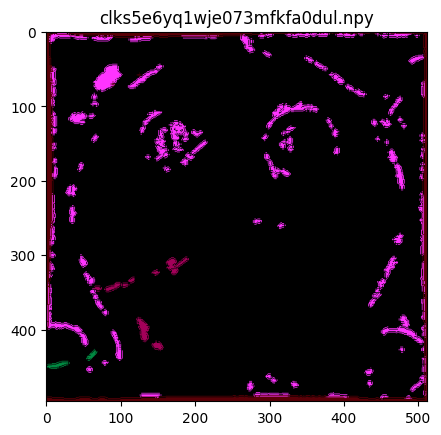

In [11]:
# Reverse mask image to rgb image for visualisation
def mask_to_rgb_image(mask):
    rgb_image = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    for class_id, rgb in id_to_rgb.items():
        rgb_image[mask == class_id] = rgb

    return rgb_image

# Load a mask image
filename = 'clks5e6yq1wje073mfkfa0dul.npy'
annotation_mask_path = join(data_dir, 'annotation_mask_path')
annotation_mask = np.load(join(annotation_mask_path, filename))

rgb_image = mask_to_rgb_image(annotation_mask)
# rgb_image = transforms.functional.to_pil_image(annotation_mask)

# Display the image
plt.title(filename)
plt.imshow(rgb_image)
plt.show()

## Create dataset splits

Here is an example of how to split the dataset for Leave-one-out cross validation (LOOCV) based on material.

In [12]:
def create_leave_one_out_splits(df, criterion='material'):

    grouped = df.groupby(criterion)
    content_splits = {name: group for name, group in grouped}
    unique_val = df[criterion].unique()

    # Initialize a dictionary to hold the train and validation sets for each LOOCV iteration
    loocv_splits = {}

    for value in unique_val:
        # Create the validation set
        val_set = content_splits[value]

        # Create the training set
        train_set = pd.concat([content_splits[c] for c in unique_val if c != value])

        # Add these to the loocv_splits dictionary
        loocv_splits[value] = {'train_set': train_set, 'val_set': val_set}

    return loocv_splits


For this coursework, we will want to assess the generalisation of the method, so for that we will keep one type of material (`Canvas`) as test set, and only train on the remaining ones.

In [13]:
# split the dataset according to material type
full_splits = create_leave_one_out_splits(df, 'material')

# use Canvas as test set
test_set = full_splits['Canvas']['val_set']

# use the rest as training set
train_set = full_splits['Canvas']['train_set']

# prepare a leave-one-out cross validation for the training set
loocv_splits = create_leave_one_out_splits(train_set, 'material')

# identify the different type of image content
unique_material = train_set['material'].unique()
print(unique_material)


['Parchment' 'Film emulsion' 'Glass' 'Paper' 'Tesserae' 'Textile'
 'Ceramic' 'Wood']


To help you, here are some helper functions to help crop and process images.

In [14]:
def random_square_crop_params(image, target_size):
    width, height = image.size
    min_edge = min(width, height)

    # Conditionally set the range for random crop size
    lower_bound = min(min_edge, target_size)
    upper_bound = max(min_edge, target_size)

    # Generate crop_size
    crop_size = random.randint(lower_bound, upper_bound)

    # Check and adjust if crop_size is larger than any dimension of the image
    if crop_size > width or crop_size > height:
        crop_size = min(width, height)

    # Generate random coordinates for the top-left corner of the crop
    x = random.randint(0, width - crop_size)
    y = random.randint(0, height - crop_size)

    return (x, y, x + crop_size, y + crop_size)

def apply_crop_and_resize(image, coords, target_size):
    image_crop = image.crop(coords)
    image_crop = image_crop.resize((target_size, target_size), Image.NEAREST)
    return image_crop

I create functions to center crop images

In [15]:
def center_square_crop_params(image, target_size):
    width, height = image.size
    min_edge = min(width, height)

    if min_edge >= target_size:
      x1 = width // 2 - target_size // 2
      y1 = height // 2 - target_size // 2
      x2 = x1 + target_size
      y2 = y1 + target_size
    else:
      aspect_ratio = width / height
      if width < height:
          new_width = target_size
          new_height = int(new_width / aspect_ratio)
      else:
          new_height = target_size
          new_width = int(new_height * aspect_ratio)

      # Calculate center crop coordinates after resizing
      x1 = new_width // 2 - target_size // 2
      y1 = new_height // 2 - target_size // 2
      x2 = x1 + target_size
      y2 = y1 + target_size

    return x1, y1, x2, y2

def apply_center_crop(image, target_size):
    crop_coords = center_square_crop_params(image, target_size)
    # For smaller images, we resize first to ensure the crop size can be achieved
    if min(image.size) < target_size:
        # Calculate new size preserving the aspect ratio
        aspect_ratio = image.width / image.height
        if image.width < image.height:
            new_width = target_size
            new_height = round(new_width / aspect_ratio)
        else:
            new_height = target_size
            new_width = round(new_height * aspect_ratio)
        image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)
    return image.crop(crop_coords)

def apply_center_crop_to_mask(mask_image, target_size):
    # Apply center cropping to the mask using nearest-neighbor interpolation
    # Get current size
    width, height = mask_image.size

    # Determine if resizing is needed
    if min(width, height) < target_size:
        aspect_ratio = width / height
        if width < height:
            new_width = target_size
            new_height = round(new_width / aspect_ratio)
        else:
            new_height = target_size
            new_width = round(new_height * aspect_ratio)
        resized_mask = mask_image.resize((new_width, new_height), Image.NEAREST)
    else:
        resized_mask = mask_image

    # Calculate center crop coordinates and crop
    crop_coords = center_square_crop_params(resized_mask, target_size)
    return resized_mask.crop(crop_coords)

We also provide a simple class for holding the dataset

Modify:

I also add annotation mask into the CustomDataset

### 1. CustomDataset Original

In [16]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import random
import numpy as np
from PIL import Image

from torchvision import transforms

class CustomDataset(Dataset):
    def __init__(self, dataframe, target_size, dataset_type="train"):
        self.dataframe = dataframe
        self.target_size = target_size
        self.dataset_type = dataset_type

        self.to_tensor = transforms.ToTensor()

        # Define the normalization transform
        self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                              std=[0.229, 0.224, 0.225])

    def __len__(self):
            return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        annotation = Image.open(row['annotation_path']).convert('L')
        annotation_rgb = Image.open(row['annotation_rgb_path']).convert('RGB')
        annotation_mask = np.load(row['annotation_mask_path'])
        id = row['id']
        material = row['material']
        content = row['content']

        if self.dataset_type == "train":
            # Generate random square cropping coordinates
            crop_coords = random_square_crop_params(image, self.target_size)

            # Apply the same cropping and resizing to all
            image = apply_crop_and_resize(image, crop_coords, self.target_size)
            annotation = apply_crop_and_resize(annotation, crop_coords, self.target_size)
            annotation_rgb = apply_crop_and_resize(annotation_rgb, crop_coords, self.target_size)
            annotation_mask = np.array(apply_crop_and_resize(transforms.functional.to_pil_image(annotation_mask), crop_coords, self.target_size))

        elif self.dataset_type == "validation":  # Validation
            max_edge = max(image.size)
            if max_edge > 1024:
                downsample_ratio = 1024 / max_edge
                new_size = tuple([int(dim * downsample_ratio) for dim in image.size])

                image = image.resize(new_size, Image.BILINEAR)
                annotation = annotation.resize(new_size, Image.NEAREST)
                annotation_rgb = annotation_rgb.resize(new_size, Image.BILINEAR)
                annotation_mask = np.array(transforms.functional.to_pil_image(annotation_mask).resize(new_size, Image.NEAREST))

        elif self.dataset_type == "test": # Test
            # Instead of cropping, downsize the images so that the longest edge is 1024 or less
            max_edge = max(image.size)
            if max_edge > 1024:
                downsample_ratio = 1024 / max_edge
                new_size = tuple([int(dim * downsample_ratio) for dim in image.size])

                image = image.resize(new_size, Image.BILINEAR)
                annotation = annotation.resize(new_size, Image.NEAREST)
                annotation_rgb = annotation_rgb.resize(new_size, Image.BILINEAR)
                annotation_mask = np.array(transforms.functional.to_pil_image(annotation_mask).resize(new_size, Image.NEAREST))

        # Convert PIL images to PyTorch tensors
        image = self.to_tensor(image)
        annotation = torch.tensor(np.array(annotation), dtype=torch.long)
        annotation_rgb = self.to_tensor(annotation_rgb)
        annotation_mask = torch.from_numpy(annotation_mask).long()

        # Normalize the image
        image = self.normalize(image)

        # Change all values in annotation that are 255 to 16
        annotation[annotation == 255] = 16

        return {
            'image': image,
            'annotation': annotation,
            'annotation_rgb': annotation_rgb,
            'annotation_mask': annotation_mask,
            'id': id,
            'material': material,
            'content': content
        }

### 2. CustomDataset with Data-augmentation

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import random
import numpy as np
from PIL import Image

from torchvision import transforms

if run_this_cell:
    class CustomDataset(Dataset):
        def __init__(self, dataframe, target_size, dataset_type="train"):
            self.dataframe = dataframe
            self.target_size = target_size
            self.dataset_type = dataset_type

            self.to_tensor = transforms.ToTensor()

            # Define the normalization transform
            self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                  std=[0.229, 0.224, 0.225])

            # Define augmentation transforms for the training dataset
            if self.dataset_type == "train":
                self.augment = transforms.Compose([
                    transforms.RandomApply([
                        transforms.RandomHorizontalFlip(),
                    ], p=0.5)
                ])
                self.color_augment = transforms.Compose([
                    transforms.RandomApply([
                        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
                        transforms.ColorJitter(brightness=0.2, contrast=0.2),
                        transforms.ColorJitter(saturation=0.2, hue=0.1),
                        transforms.ColorJitter(brightness=0.2, saturation=0.1, hue=0.2),
                    ], p=0.8),
                ])
            else:
                self.augment = transforms.Compose([])  # No augmentation for validation/test dataset
                self.color_augment = transforms.Compose([])

        def __len__(self):
                return len(self.dataframe)

        def __getitem__(self, idx):
            row = self.dataframe.iloc[idx]
            image = Image.open(row['image_path']).convert('RGB')
            annotation = Image.open(row['annotation_path']).convert('L')
            annotation_rgb = Image.open(row['annotation_rgb_path']).convert('RGB')
            annotation_mask = np.load(row['annotation_mask_path'])
            id = row['id']
            material = row['material']
            content = row['content']

            if self.dataset_type == "train":
                # Apply color augmentations to the image only (before converting to tensor)
                image = self.color_augment(image)

                # Convert PIL image and mask to Torch tensor for augmentation
                image_tensor = self.to_tensor(image)
                annotation_tensor = self.to_tensor(annotation)
                rgb_tensor = self.to_tensor(annotation_rgb)
                mask_tensor = torch.from_numpy(annotation_mask).unsqueeze(0)  # Add channel dimension to mask

                # Stack image and mask to ensure the same transformation is applied
                combined = torch.cat((image_tensor, rgb_tensor, mask_tensor), dim=0)

                # Apply augmentation to combined image and mask
                combined_augmented = self.augment(combined)

                # Split the image and mask
                image_augmented = combined_augmented[:3, :, :]  # First three channels for image
                # annotation_augmented = combined_augmented[3:6, :, :] # Next three channels for annotation
                rgb_augmented = combined_augmented[3:6, :, :] # Next three channels for rgb annotation
                mask_augmented = combined_augmented[6, :, :].squeeze()  # Last channel for mask annotation

                # Convert augmented data back to original type
                image = transforms.ToPILImage()(image_augmented)
                # annotation = transforms.ToPILImage()(annotation_augmented)
                annotation_rgb = transforms.ToPILImage()(rgb_augmented)
                annotation_mask = np.array(mask_augmented.byte())

                # Generate random square cropping coordinates
                crop_coords = random_square_crop_params(image, self.target_size)

                # Apply the same cropping and resizing to all
                image = apply_crop_and_resize(image, crop_coords, self.target_size)
                annotation = apply_crop_and_resize(annotation, crop_coords, self.target_size)
                annotation_rgb = apply_crop_and_resize(annotation_rgb, crop_coords, self.target_size)
                annotation_mask = np.array(apply_crop_and_resize(transforms.functional.to_pil_image(annotation_mask), crop_coords, self.target_size))

            elif self.dataset_type == "validation":  # Validation
                max_edge = max(image.size)
                if max_edge > 1024:
                    downsample_ratio = 1024 / max_edge
                    new_size = tuple([int(dim * downsample_ratio) for dim in image.size])

                    image = image.resize(new_size, Image.BILINEAR)
                    annotation = annotation.resize(new_size, Image.NEAREST)
                    annotation_rgb = annotation_rgb.resize(new_size, Image.BILINEAR)
                    annotation_mask = np.array(transforms.functional.to_pil_image(annotation_mask).resize(new_size, Image.NEAREST))

                # # Apply center square cropping to all
                # image = apply_center_crop(image, self.target_size)
                # annotation = apply_center_crop(annotation, self.target_size)
                # annotation_rgb = apply_center_crop(annotation_rgb, self.target_size)
                # annotation_mask = np.array(apply_center_crop_to_mask(transforms.functional.to_pil_image(annotation_mask), self.target_size))

            elif self.dataset_type == "test": # Test
                # Instead of cropping, downsize the images so that the longest edge is 1024 or less
                max_edge = max(image.size)
                if max_edge > 1024:
                    downsample_ratio = 1024 / max_edge
                    new_size = tuple([int(dim * downsample_ratio) for dim in image.size])

                    image = image.resize(new_size, Image.BILINEAR)
                    annotation = annotation.resize(new_size, Image.NEAREST)
                    annotation_rgb = annotation_rgb.resize(new_size, Image.BILINEAR)
                    annotation_mask = np.array(transforms.functional.to_pil_image(annotation_mask).resize(new_size, Image.NEAREST))

            # Convert PIL images to PyTorch tensors
            image = self.to_tensor(image)
            annotation = torch.tensor(np.array(annotation), dtype=torch.long)
            annotation_rgb = self.to_tensor(annotation_rgb)
            annotation_mask = torch.from_numpy(annotation_mask).long()

            # Normalize the image
            image = self.normalize(image)

            # Change all values in annotation that are 255 to 16
            annotation[annotation == 255] = 16

            return {
                'image': image,
                'annotation': annotation,
                'annotation_rgb': annotation_rgb,
                'annotation_mask': annotation_mask,
                'id': id,
                'material': material,
                'content': content
            }

### CustomDataModule
Here we create a DataModule which encapsulates our training and validation DataLoaders; you can also do this manually by only using the Pytorch DataLoader class, lines 24 and 27.

In [17]:
from torch.utils.data import DataLoader

class CustomDataModule(pl.LightningDataModule):
    def __init__(self, loocv_splits, current_material, target_size, batch_size=32, num_workers=4):
        super().__init__()
        self.loocv_splits = loocv_splits
        self.current_material = current_material
        self.target_size = target_size
        self.batch_size = batch_size
        self.num_workers = num_workers

    def prepare_data(self):
        pass

    def setup(self, stage=None):
        # Load current train and validation set based on LOOCV iteration
        train_df = self.loocv_splits[self.current_material]['train_set']
        val_df = self.loocv_splits[self.current_material]['val_set'].sample(frac=1).reset_index(drop=True)

        self.train_dataset = CustomDataset(dataframe=train_df, target_size=self.target_size, dataset_type="train")
        self.val_dataset = CustomDataset(dataframe=val_df, target_size=self.target_size, dataset_type="validation")
        self.test_dataset = CustomDataset(dataframe=val_df, target_size=self.target_size, dataset_type="test")

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=1, shuffle=False, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=1, shuffle=False, num_workers=self.num_workers)


# Dataset visualisation

We need to denormalise the images so we can display them

In [18]:
# Mean and std used for normalization
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

def denormalize(image, mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]):
    img_cpy = image.copy()
    for i in range(3):
        img_cpy[..., i] = img_cpy[..., i] * std[i] + mean[i]
    return img_cpy

The following will create a data module for validating on the first content in the list (`Parchment`) and training on all the other types of material (you will want to do that for each fold).

In [ ]:
data_module = CustomDataModule(loocv_splits=loocv_splits,
                               current_material=unique_material[0],
                               target_size=512,
                               batch_size=4)

Finally, we can get the train and validation data loaders from the data module.

In [ ]:
data_module.setup()
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()

## Visualise training samples
Random square crops of the images and correspoding RGB annotations on their own and overlaid onto the image.

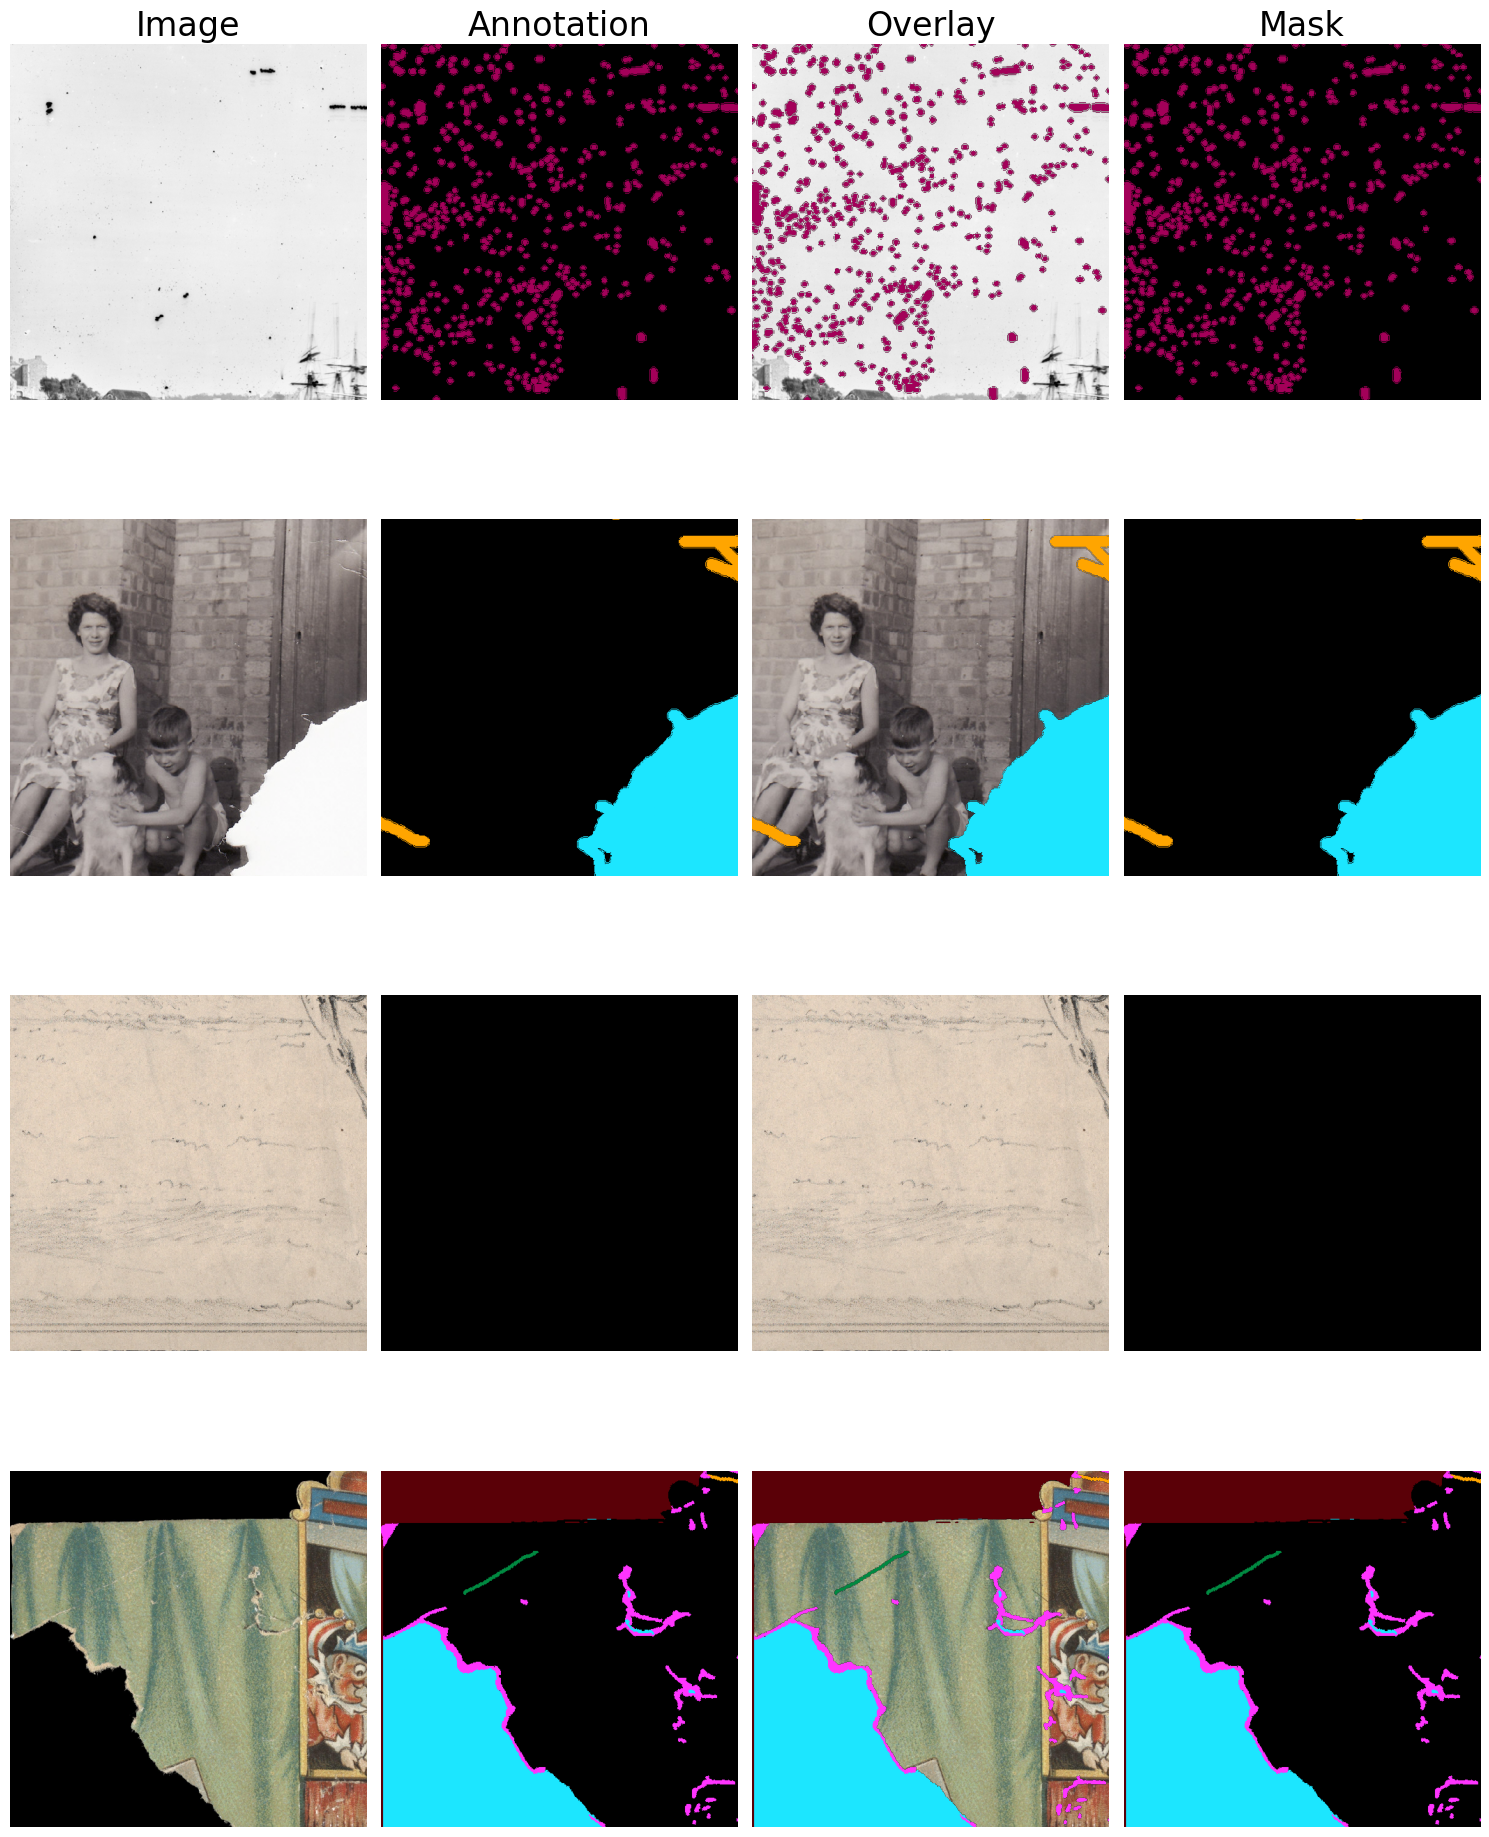

In [ ]:
example_batch = next(iter(train_loader))

example_images = example_batch['image']
example_annotations = example_batch['annotation']
example_annotation_rgbs = example_batch['annotation_rgb']
example_annotation_masks = example_batch['annotation_mask']

# Number of examples to visualize
N = min(4, len(example_images))

fig, axes = plt.subplots(N, 4, figsize=(15, 5 * N))

for ax, col in zip(axes[0], ['Image', 'Annotation', 'Overlay', 'Mask']):
    ax.set_title(col, fontsize=24)

for i in range(N):
    example_image = denormalize(example_images[i].numpy().transpose((1, 2, 0)), mean, std)  # C, H, W -> H, W, C
    example_annotation = Image.fromarray(np.uint8(example_annotations[i].numpy()), 'L')
    example_annotation_rgb = example_annotation_rgbs[i].numpy().transpose((1, 2, 0))  # C, H, W -> H, W, C

    # Convert annotation mask to rgb image for visualisation
    example_annotation_mask = mask_to_rgb_image(example_annotation_masks[i])

    # Create an alpha (transparency) channel where black pixels in annotation_rgb are fully transparent
    alpha_channel = np.all(example_annotation_rgb == [0, 0, 0], axis=-1)
    example_annotation_rgba = np.dstack((example_annotation_rgb, np.where(alpha_channel, 0, 1)))

    axes[i, 0].imshow(example_image)
    axes[i, 0].axis('off')

    #axes[i, 1].imshow(example_annotation, cmap='gray', vmin=0, vmax=255)
    axes[i, 1].imshow(example_annotation_rgb)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(example_image)
    axes[i, 2].imshow(example_annotation_rgba)
    axes[i, 2].axis('off')

    # Added visualisation of the annotation mask
    axes[i, 3].imshow(example_annotation_mask)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

Visualising the validation set, which loads the left-out class as whole images.

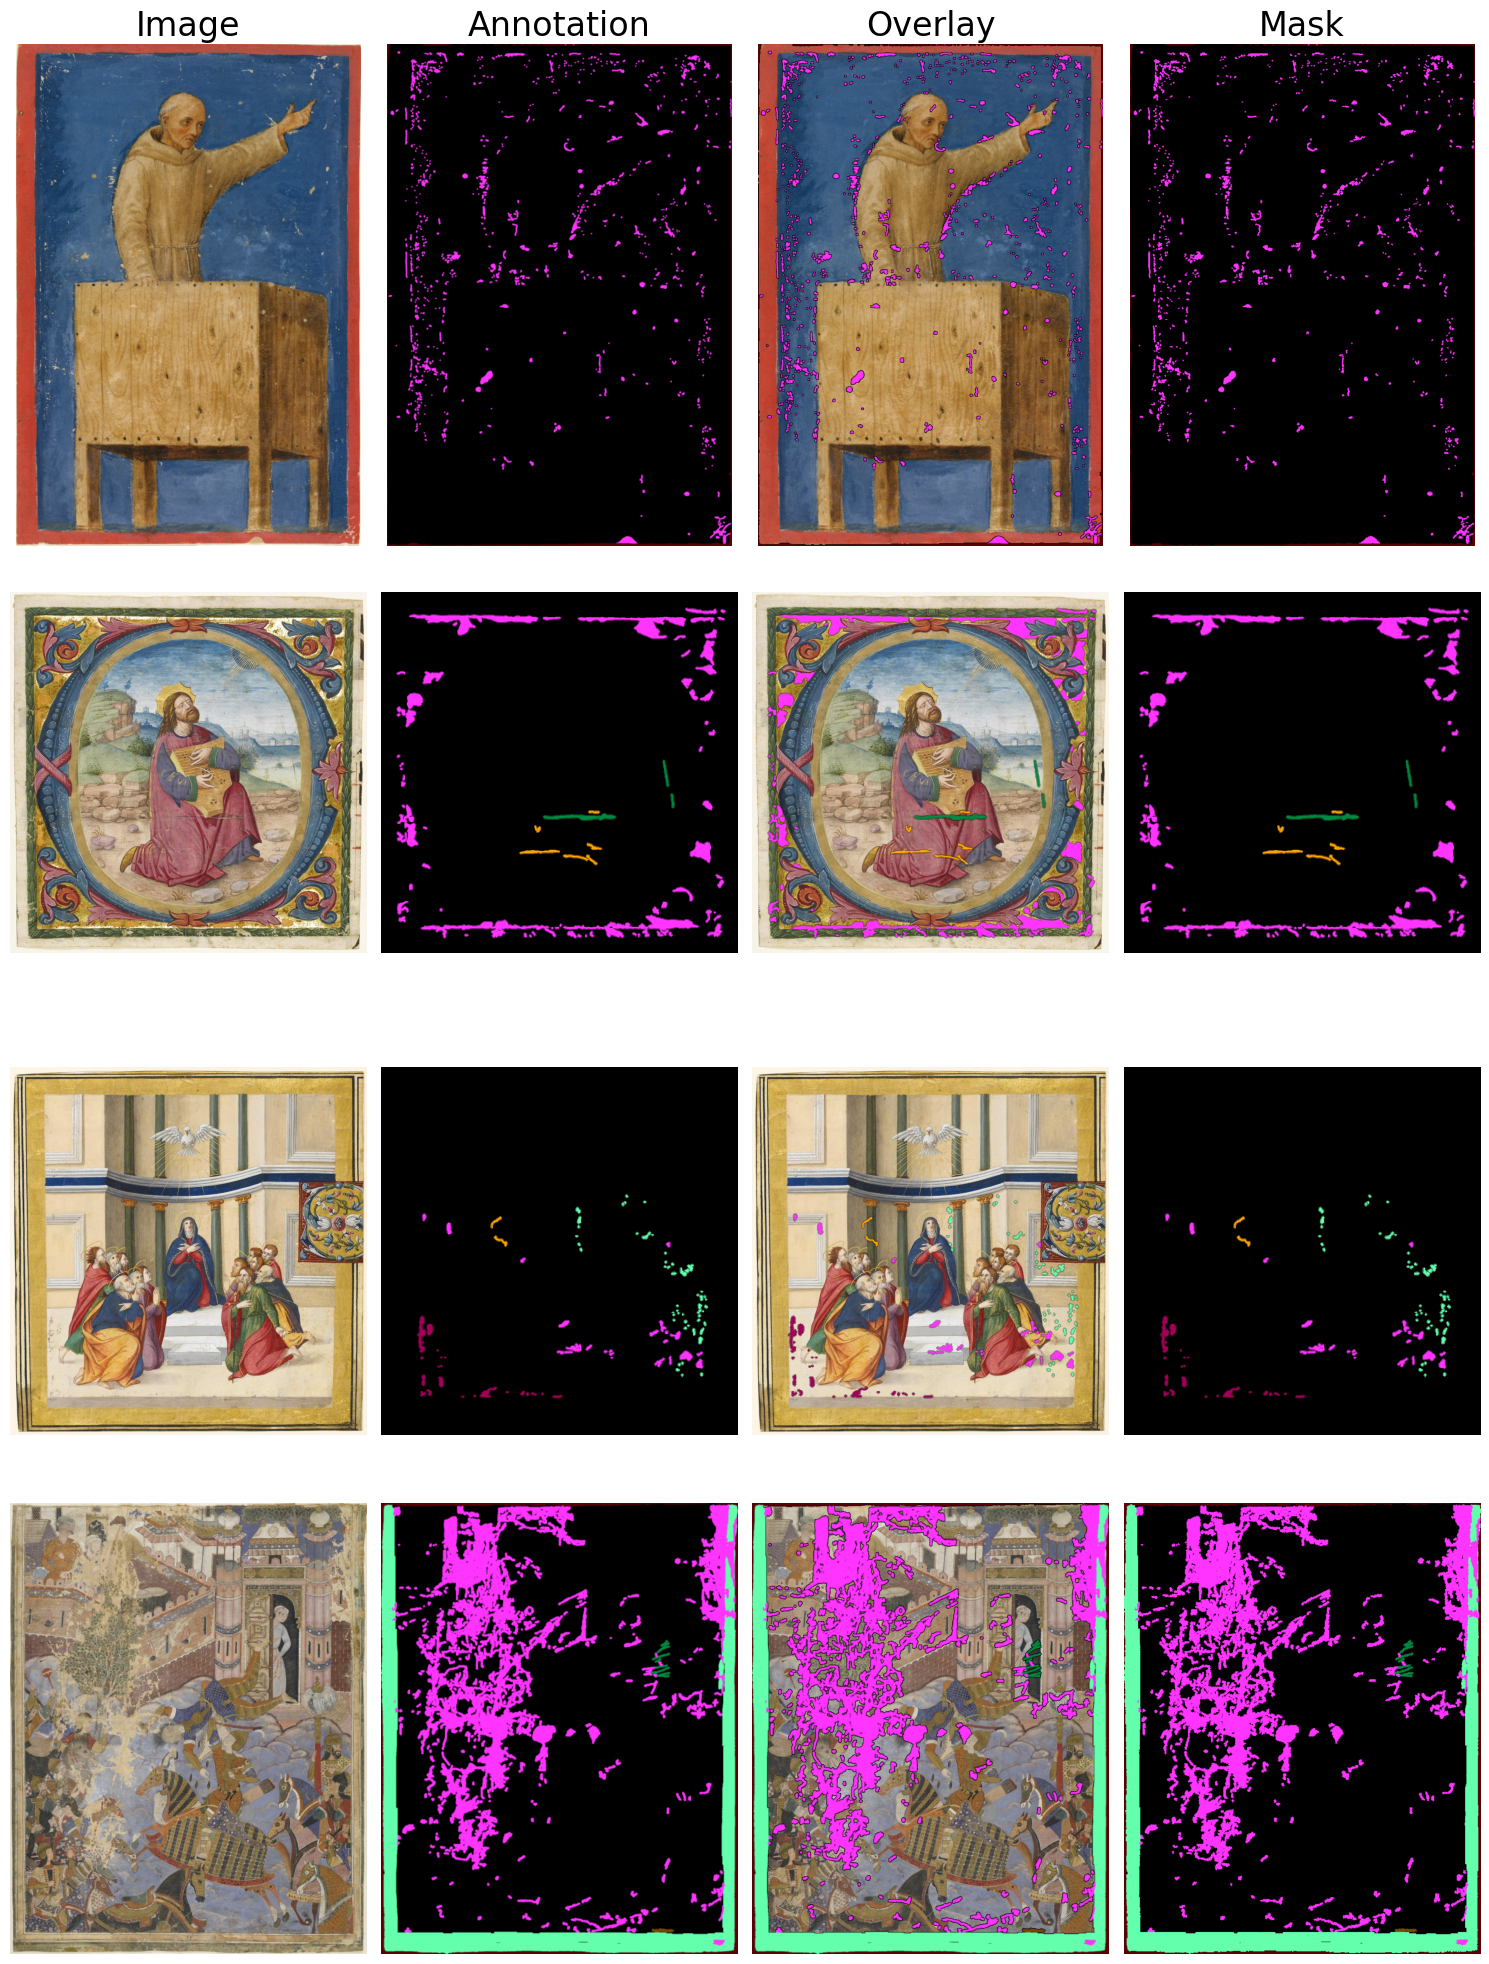

In [ ]:
val_iter = iter(val_loader)
example_batches = [next(val_iter) for _ in range(4)]

# Initialize empty lists to collect different parts of each batch
example_images = []
example_annotations = []
example_annotation_rgbs = []
example_annotation_masks = []
example_materials = []
example_contents = []

# Populate the lists with the data from the 4 batches
for batch in example_batches:
    example_images.append(batch['image'].squeeze())
    example_annotations.append(batch['annotation'].squeeze())
    example_annotation_rgbs.append(batch['annotation_rgb'].squeeze())
    example_annotation_masks.append(batch['annotation_mask'].squeeze())
    example_materials.append(batch['material'][0])
    example_contents.append(batch['content'][0])

# Number of examples to visualize
N = min(4, len(example_images))

fig, axes = plt.subplots(N, 4, figsize=(15, 5 * N))

for ax, col in zip(axes[0], ['Image', 'Annotation', 'Overlay', 'Mask']):
    ax.set_title(col, fontsize=24)

for i in range(N):
    example_image = denormalize(example_images[i].numpy().transpose((1, 2, 0)), mean, std)  # C, H, W -> H, W, C
    example_annotation = example_annotations[i].numpy()
    example_annotation_rgb = example_annotation_rgbs[i].numpy().transpose((1, 2, 0))  # C, H, W -> H, W, C

    # Convert annotation mask to rgb image for visualisation
    example_annotation_mask = mask_to_rgb_image(example_annotation_masks[i])

    example_material = example_materials[i]
    example_content = example_contents[i]
    # Create an alpha (transparency) channel where black pixels in annotation_rgb are fully transparent
    alpha_channel = np.all(example_annotation_rgb == [0, 0, 0], axis=-1)
    example_annotation_rgba = np.dstack((example_annotation_rgb, np.where(alpha_channel, 0, 1)))
    axes[i, 0].imshow(example_image)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(example_annotation_rgb)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(example_image)
    axes[i, 2].imshow(example_annotation_rgba)
    axes[i, 2].axis('off')

    axes[i, 3].imshow(example_annotation_mask)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

# Train Model

We are planning to do semantic segmentation for the coursework. Hence, we will be using Fully Convolutional Networks to retain the spatial information.

## Model architectures

### 1. VGGUNet
When the model is trained for the task of semantic segmentation, the encoder outputs a tensor containing information about the objects, and its shape and size. The decoder takes this information and produces the segmentation maps.

In this coursework, we will be utilizing pretrained vgg16 models with UNET architecture.

In [ ]:
class VGGUNet(nn.Module):
    def __init__(self, num_classes):
        super(VGGUNet, self).__init__()
        # Load the pre-trained VGG model features
        vgg_features = models.vgg16(pretrained=True).features

        # Select blocks from the VGG model to act as the downsample path
        self.encoder1 = vgg_features[:4]   # First conv block
        self.encoder2 = vgg_features[5:9]  # Second conv block
        self.encoder3 = vgg_features[10:16] # Third conv block
        self.encoder4 = vgg_features[17:23] # Fourth conv block

        # Upsample path (Decoder)
        self.decoder1 = self._decoder_block(512, 512, 256)
        self.decoder2 = self._decoder_block(256, 256, 128)
        self.decoder3 = self._decoder_block(128, 128, 64)
        self.decoder4 = self._decoder_block(64, 64, 32)

        # Final classifier layer
        self.final_layer = nn.Conv2d(32, num_classes, kernel_size=1)

    def _decoder_block(self, in_channels, middle_channels, out_channels):
        layers = [
            nn.Conv2d(in_channels, middle_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(middle_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        ]
        return nn.Sequential(*layers)

    def forward(self, x):
        # Encoder path
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)

        # Decoder path
        d1 = self.decoder1(e4)
        d2 = self.decoder2(d1)
        d3 = self.decoder3(d2)
        d4 = self.decoder4(d3)

        # Classifier
        out = self.final_layer(d4)
        return out

Initialize the model

In [ ]:
if run_this_cell:
    num_classes = len(id2label)
    model = VGGUNet(num_classes).to(DEVICE)
    print(model)

    # Optionally freeze the encoder layers
    for param in model.encoder1.parameters():
        param.requires_grad = False
    for param in model.encoder2.parameters():
        param.requires_grad = False
    for param in model.encoder3.parameters():
        param.requires_grad = False
    for param in model.encoder4.parameters():
        param.requires_grad = False

### 2. MobileNetV2

In [ ]:
class MobileNetV2Segmentation(nn.Module):
    def __init__(self, num_classes):
        super(MobileNetV2Segmentation, self).__init__()
        mobilenet = models.mobilenet_v2(pretrained=True)
        self.features = mobilenet.features

        # Adjust the number of upsampling layers based on the input size and MobileNetV2's downsampling factor
        # For an input of 512x512, and assuming MobileNetV2 downsamples by 32x, you need sufficient upsampling to match
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(1280, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, num_classes, kernel_size=3, stride=2, padding=1, output_padding=1)  # This layer adjusts the channel to match the number of classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.upsample(x)
        # Additional resizing might be necessary if the output still doesn't match the input size
        return x

Initialize the model

In [ ]:
if run_this_cell:
    num_classes = len(id2label)
    model = MobileNetV2Segmentation(num_classes).to(DEVICE)
    print(model)

### 3. DeepLabV3

ResNet50

In [ ]:
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights

if run_this_cell:
    # Load pre-trained weights
    weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1

    deeplabv3_model = models.segmentation.deeplabv3_resnet50(weights=weights, progress=True, aux_loss=None)

    # Modify the classifier to fit the number of classes for your dataset
    deeplabv3_model.classifier[4] = nn.Conv2d(deeplabv3_model.classifier[4].in_channels,
                                              len(id2label),
                                              kernel_size=deeplabv3_model.classifier[4].kernel_size)

    model = deeplabv3_model.to(DEVICE)

ResNet101

In [ ]:
from torchvision.models.segmentation import DeepLabV3_ResNet101_Weights

# Load pre-trained weights
weights = DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1

deeplabv3_model = models.segmentation.deeplabv3_resnet101(weights=weights, progress=True, aux_loss=None)

# Modify the classifier to fit the number of classes for your dataset
deeplabv3_model.classifier[4] = nn.Conv2d(deeplabv3_model.classifier[4].in_channels,
                                           len(id2label),
                                           kernel_size=deeplabv3_model.classifier[4].kernel_size)

model = deeplabv3_model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth
100%|██████████| 233M/233M [00:01<00:00, 132MB/s]


## Model Training

Adjust parameters (ex.batch size and learning rate)

In [19]:
# 1. VGGUNet
# target_size = 512
# batch_size = 16
# learning_rate = 0.0005
# num_epochs = 30

# 2. MobileNetV2
# target_size = 512
# batch_size = 64
# learning_rate = 0.0001
# num_epochs = 50

# 3. DeepLabV3 ResNet50
# target_size = 512
# batch_size = 21
# learning_rate = 0.00009
# num_epochs = 100

# 4. DeepLabV3 ResNet101
target_size = 512
batch_size = 13
learning_rate = 0.0001
num_epochs = 100

Create a new data module

In [20]:
data_module = CustomDataModule(loocv_splits=loocv_splits,
                               current_material=unique_material[2],
                               target_size=target_size,
                               batch_size=batch_size)
data_module.setup()
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()

### Initialize Loss

1. Cross-Entropy Loss

In [21]:
criterion = nn.CrossEntropyLoss()

2. Dice Loss

In [ ]:
class MultiClassDiceLoss(nn.Module):
    def __init__(self, smooth=1., ignore_index=None):
        super(MultiClassDiceLoss, self).__init__()
        self.smooth = smooth
        self.ignore_index = ignore_index

    def forward(self, inputs, targets):
        # inputs: [N, C, H, W] Variable with logits (not probabilities) from the model
        # targets: [N, H, W] LongTensor with class indices
        inputs = torch.softmax(inputs, dim=1)

        C = inputs.shape[1]
        dice_loss = 0.
        for c in range(C):
            if c != self.ignore_index:  # Optional: Ignore a certain class index
                target_c = (targets == c).float()
                input_c = inputs[:, c]
                intersection = (input_c * target_c).sum()
                dice_c = (2. * intersection + self.smooth) / (input_c.sum() + target_c.sum() + self.smooth)
                dice_loss += (1 - dice_c)

        return dice_loss / (C - (1 if self.ignore_index is not None else 0))

if run_this_cell:
    # Initialize the combined loss
    criterion = MultiClassDiceLoss(smooth=1.0)

3. Combine Dice and Cross-Entropy Loss

In [ ]:
class CombinedDiceCrossEntropyLoss(nn.Module):
    def __init__(self, dice_smooth=1., dice_weight=0.5, ce_weight=0.5, ignore_index=None):
        super(CombinedDiceCrossEntropyLoss, self).__init__()
        self.dice_smooth = dice_smooth
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight
        self.ignore_index = ignore_index

    def forward(self, inputs, targets):
        # Compute Dice Loss
        inputs_softmax = torch.softmax(inputs, dim=1)
        C = inputs_softmax.shape[1]
        dice_loss = 0.
        for c in range(C):
            if c != self.ignore_index:
                target_c = (targets == c).float()
                input_c = inputs_softmax[:, c]
                intersection = (input_c * target_c).sum()
                dice_c = (2. * intersection + self.dice_smooth) / (input_c.sum() + target_c.sum() + self.dice_smooth)
                dice_loss += (1 - dice_c)
        dice_loss /= (C - (1 if self.ignore_index is not None else 0))

        # Compute CrossEntropy Loss with conditional ignore_index
        if self.ignore_index is not None:
            ce_loss = F.cross_entropy(inputs, targets, ignore_index=self.ignore_index)
        else:
            ce_loss = F.cross_entropy(inputs, targets)

        # Combine the losses
        combined_loss = self.dice_weight * dice_loss + self.ce_weight * ce_loss
        return combined_loss

if run_this_cell:
    # Example usage
    criterion = CombinedDiceCrossEntropyLoss(dice_smooth=1.0, dice_weight=0.4, ce_weight=0.6, ignore_index=None)

### Train the Model

Since we are doing segmetation task and segmentation is a classification problem at each pixel, the suitable loss function is Cross-Entropy Loss `nn.CrossEntropyLoss`, which is commonly used for multi-class classification tasks.

In [ ]:
if run_this_cell:
    # Store training and validation loss
    train_losses = []
    validation_losses = []

    # VGGUNet
    # optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

    # Others
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Early stopping initialization
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0

    # Example training loop
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            inputs = batch['image'].to(DEVICE)
            annotation_masks = batch['annotation_mask'].to(DEVICE)

            # Forward pass
            # outputs = model(inputs)         # Other models
            outputs = model(inputs)['out']    # DeepLabV3
            loss = criterion(outputs, annotation_masks)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        # Calculate average losses
        train_loss = train_loss / len(train_loader.dataset)

        # Validation phase
        model.eval()  # Set the model to evaluation mode
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                inputs = batch['image'].to(DEVICE)
                annotation_masks = batch['annotation_mask'].to(DEVICE)

                # Forward pass
                # outputs = model(inputs)         # Other models
                outputs = model(inputs)['out']    # DeepLabV3
                loss = criterion(outputs, annotation_masks)

                val_loss += loss.item() * inputs.size(0)

            # Calculate average losses
            val_loss = val_loss / len(val_loader.dataset)

        # Append train loss and validation loss
        train_losses.append(np.round(train_loss, 6))
        validation_losses.append(np.round(val_loss, 6))

        # Print training/validation statistics
        print(f'Epoch: {epoch+1}/{num_epochs} \tTraining Loss: {train_loss:.6f} \tValidation Loss: {val_loss:.6f}')

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # Reset patience counter
            temp_model = model
        else:
            patience_counter += 1  # Increment patience counter

            # Save the best acquired model training so far
            if patience_counter == 1:
              model_save = f'deeplabv3_resnet50_model-epoch{epoch+1}.pth'
              torch.save(temp_model, model_save)

        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1:02d} epochs.")
            break


### Train the Model with Mix Precision Training

In [22]:
if run_this_cell:
    # Store training and validation loss
    train_losses = []
    validation_losses = []

    # VGGUNet
    # optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

    # Others
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Initialize the learning rate scheduler
    # scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
    scheduler = ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.7, verbose=True)

    # Early stopping initialization
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0

    # Initialize the gradient scaler
    scaler = GradScaler()

    # Example training loop
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            inputs = batch['image'].to(DEVICE)
            annotation_masks = batch['annotation_mask'].to(DEVICE)

            optimizer.zero_grad()

            # Forward pass with autocast
            with autocast():
                # outputs = model(inputs)         # Other models
                outputs = model(inputs)['out']    # DeepLabV3
                loss = criterion(outputs, annotation_masks)

            # Backward and optimize
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * inputs.size(0)

        # Calculate average losses
        train_loss = train_loss / len(train_loader.dataset)

        # Validation phase
        model.eval()  # Set the model to evaluation mode
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                inputs = batch['image'].to(DEVICE)
                annotation_masks = batch['annotation_mask'].to(DEVICE)

                # Forward pass with autocast
                with autocast():
                    # outputs = model(inputs)             # Other models
                    outputs = model(inputs)['out']        # DeepLabV3
                    loss = criterion(outputs, annotation_masks)
                    preds = torch.softmax(outputs, dim=1)  # Convert logits to probabilities

                val_loss += loss.item() * inputs.size(0)

        # Calculate average losses
        val_loss = val_loss / len(val_loader.dataset)

        # Append train loss and validation loss
        train_losses.append(np.round(train_loss, 6))
        validation_losses.append(np.round(val_loss, 6))

        best_model_so_far = True
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # Reset patience counter
            temp_model = model
            best_model_so_far = True
        else:
            patience_counter += 1  # Increment patience counter
            best_model_so_far = False

            # Save the best acquired model training so far
            if patience_counter == 1:
              model_save = f'deeplabv3_resnet100_model-epoch{epoch}.pth'
              torch.save(temp_model, model_save)

        # Print training/validation statistics
        if best_model_so_far:
          print(f'Epoch: {epoch+1}/{num_epochs} \tTraining Loss: {train_loss:.6f} \tValidation Loss: {val_loss:.6f} (Best so far!)')
        else:
          print(f'Epoch: {epoch+1}/{num_epochs} \tTraining Loss: {train_loss:.6f} \tValidation Loss: {val_loss:.6f}')

        # Step the scheduler
        # scheduler.step()
        scheduler.step(val_loss)

        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break


### Train Model with PyTorch Lightning

In [ ]:
if run_this_cell:
    class SemanticSegmentationModule(pl.LightningModule):
        def __init__(self, model, num_classes, lr, criterion):
            super().__init__()
            self.model = model
            self.num_classes = num_classes
            self.lr = lr
            self.criterion = criterion
            self.save_hyperparameters()

        def forward(self, x):
            return self.model(x)

        def training_step(self, batch, batch_idx):
            inputs, annotation_masks = batch['image'], batch['annotation_mask']
            outputs = self(inputs)['out']  # DeepLabV3
            loss = self.criterion(outputs, annotation_masks)
            self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)
            return loss

        def validation_step(self, batch, batch_idx):
            inputs, annotation_masks = batch['image'], batch['annotation_mask']
            outputs = self(inputs)['out']  # DeepLabV3
            loss = self.criterion(outputs, annotation_masks)
            self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)

        def configure_optimizers(self):
            optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
            lr_scheduler = {'scheduler': scheduler, 'interval': 'epoch', 'frequency': 1}
            return [optimizer], [lr_scheduler]

    # Create a PyTorch Lightning trainer
    checkpoint_callback = ModelCheckpoint(dirpath='checkpoints/', save_top_k=1, verbose=True, monitor='val_loss', mode='min')
    lr_monitor = LearningRateMonitor(logging_interval='step')
    early_stop_callback = EarlyStopping(monitor='val_loss', patience=10, verbose=True, mode='min')

    trainer = Trainer(
        max_epochs=100,
        callbacks=[checkpoint_callback, lr_monitor, early_stop_callback],
        precision="16-mixed",  # Enable mixed precision training
        accelerator="auto",
        devices="auto",
        strategy="auto"
    )

    # Initialize your Lightning module and fit the model
    lightning_module = SemanticSegmentationModule(model=deeplabv3_model, num_classes=len(id2label), lr=0.001, criterion=criterion)
    trainer.fit(lightning_module, train_loader, val_loader)

In [ ]:
if run_this_cell:
    # Access the logged metrics
    metrics = trainer.logged_metrics
    val_losses = metrics['val_loss']

    # Load the checkpoint
    checkpoint = torch.load('checkpoints/epoch=9-step=150.ckpt', map_location=lambda storage, loc: storage)
    state_dict = checkpoint['state_dict']
    adjusted_state_dict = {key.replace('model.', ''): value for key, value in state_dict.items()}
    model.load_state_dict(adjusted_state_dict)

    # Save the model
    model_save_path1 = 'deeplabv3_resnet50_model_state_dict.pth'
    model_save_path2 = 'deeplabv3_resnet50_model.pth'

    torch.save(trainer.model.state_dict(), model_save_path1)
    torch.save(trainer.model, model_save_path2)

### Visualise and Save Trained Model

Visualise Train and Validation Loss during model training

In [ ]:
if run_this_cell:
    plt.figure()
    plt.title('Train and Validation Losses During Model Training')
    plt.xlabel('Epoch Number')
    plt.ylabel('Loss')
    plt.plot(train_losses, label="Train set")
    plt.plot(validation_losses, label="Validation set")
    plt.legend()
    plt.show()

Save the model

In [ ]:
if run_this_cell:
    # Saving model state dictionary
    # 1. VGGUNet
    # model_save_path1 = 'vgg_unet_model_state_dict.pth'  # Saving model state dictionary
    # model_save_path2 = 'vgg_unet_model.pth'             # Saving entire model

    # 2. MobileNetV2
    # model_save_path1 = 'mobilenet_model_state_dict.pth'   # Saving model state dictionary
    # model_save_path2 = 'mobilenet_model.pth'              # Saving entire model

    # 3. DeepLabV3
    model_save_path1 = 'deeplabv3_resnet100_model_state_dict.pth'   # Saving model state dictionary
    model_save_path2 = 'deeplabv3_resnet100_model.pth'              # Saving entire model

    # Save model
    torch.save(model.state_dict(), model_save_path1)   # Save model state
    torch.save(model, model_save_path2)                # Save entire model

# Evaluation

For the final evaluation of the model, make sure to test performance on the left out category, `Canvas` to have a fair idea on how well the model generalises.

In [23]:
test_module = CustomDataModule(loocv_splits=full_splits,
                               current_material='Canvas',
                               target_size=target_size,
                               batch_size=batch_size)

test_module.setup()

test_loader = test_module.test_dataloader()


## Visualise Test Samples

I have modified the visualisation code given to visualise the images in the test samples

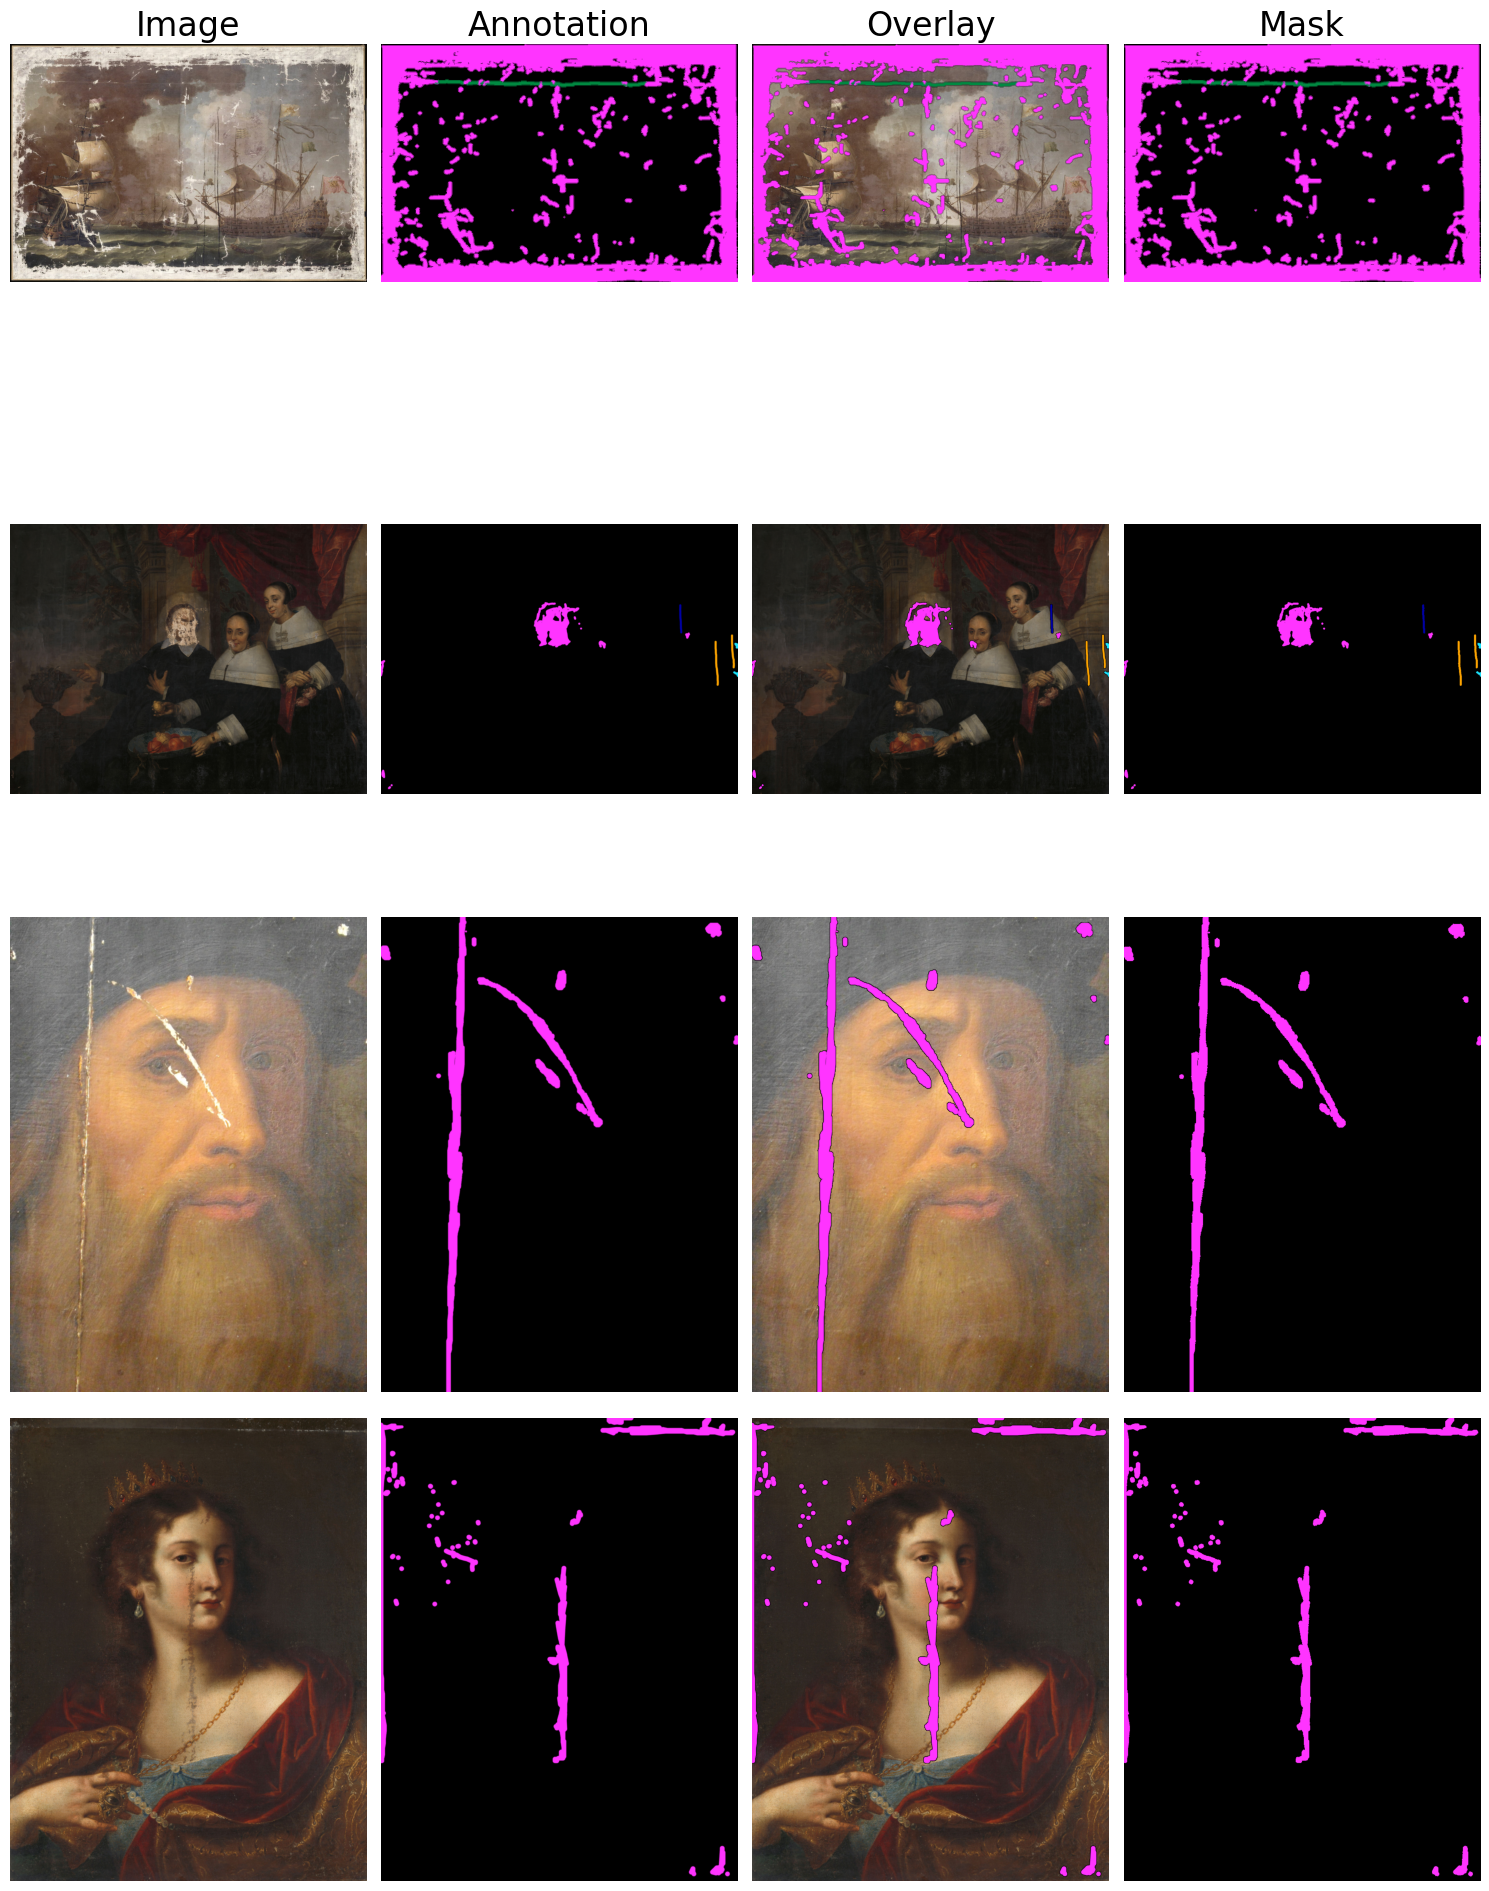

In [ ]:
test_iter = iter(test_loader)
example_batches = [next(test_iter) for _ in range(4)]

# Initialize empty lists to collect different parts of each batch
example_images = []
example_annotations = []
example_annotation_rgbs = []
example_annotation_masks = []
example_materials = []
example_contents = []

# Populate the lists with the data from the 4 batches
for batch in example_batches:
    example_images.append(batch['image'].squeeze())
    example_annotations.append(batch['annotation'].squeeze())
    example_annotation_rgbs.append(batch['annotation_rgb'].squeeze())
    example_annotation_masks.append(batch['annotation_mask'].squeeze())
    example_materials.append(batch['material'][0])
    example_contents.append(batch['content'][0])

# Number of examples to visualize
N = min(4, len(example_images))

fig, axes = plt.subplots(N, 4, figsize=(15, 5 * N))

for ax, col in zip(axes[0], ['Image', 'Annotation', 'Overlay', 'Mask']):
    ax.set_title(col, fontsize=24)

for i in range(N):
    example_image = denormalize(example_images[i].numpy().transpose((1, 2, 0)), mean, std)  # C, H, W -> H, W, C
    example_annotation = example_annotations[i].numpy()
    example_annotation_rgb = example_annotation_rgbs[i].numpy().transpose((1, 2, 0))  # C, H, W -> H, W, C

    # Convert annotation mask to rgb image for visualisation
    example_annotation_mask = mask_to_rgb_image(example_annotation_masks[i])

    example_material = example_materials[i]
    example_content = example_contents[i]
    # Create an alpha (transparency) channel where black pixels in annotation_rgb are fully transparent
    alpha_channel = np.all(example_annotation_rgb == [0, 0, 0], axis=-1)
    example_annotation_rgba = np.dstack((example_annotation_rgb, np.where(alpha_channel, 0, 1)))
    axes[i, 0].imshow(example_image)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(example_annotation_rgb)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(example_image)
    axes[i, 2].imshow(example_annotation_rgba)
    axes[i, 2].axis('off')

    axes[i, 3].imshow(example_annotation_mask)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

## Predict Test Dataset
Load pre-trained autoencoder model

In [24]:
# Other models
# model = torch.load("mobilenet_model.pth")

# DeepLabV3
model = torch.load("./damage_data/deeplabv3_resnet100_model2-epoch22.pth", map_location=torch.device('cpu'))  # CPU
# model = torch.load("./damage_data/deeplabv3_resnet100_model2-epoch22.pth")                                  # GPU

model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

Predict with test dataset and compute the loss

In [ ]:
# criterion = nn.CrossEntropyLoss()

test_loss = 0.0
with torch.no_grad():
  for batch in test_loader:
    # inputs = batch['image'].to(DEVICE)
    # annotation_masks = batch['annotation_mask'].to(DEVICE)
    inputs = batch['image']
    annotation_masks = batch['annotation_mask']

    # Forward pass
    # outputs = model(inputs)         # Other models
    outputs = model(inputs)['out']    # DeepLabV3
    loss = criterion(outputs, annotation_masks)

    test_loss += loss.item() * inputs.size(0)

  # Calculate average losses
  test_loss = test_loss / len(test_loader.dataset)

  # Print test statistics
  print(f'Testing Loss: {test_loss:.6f}')

Testing Loss: 0.501815


### Visualise Generated Output Images

Unique Class ID: [0 2]
Unique Class ID: [0 2]
Unique Class ID: [0 1 2]
Unique Class ID: [ 0  2  7 10]
Unique Class ID: [0 7]


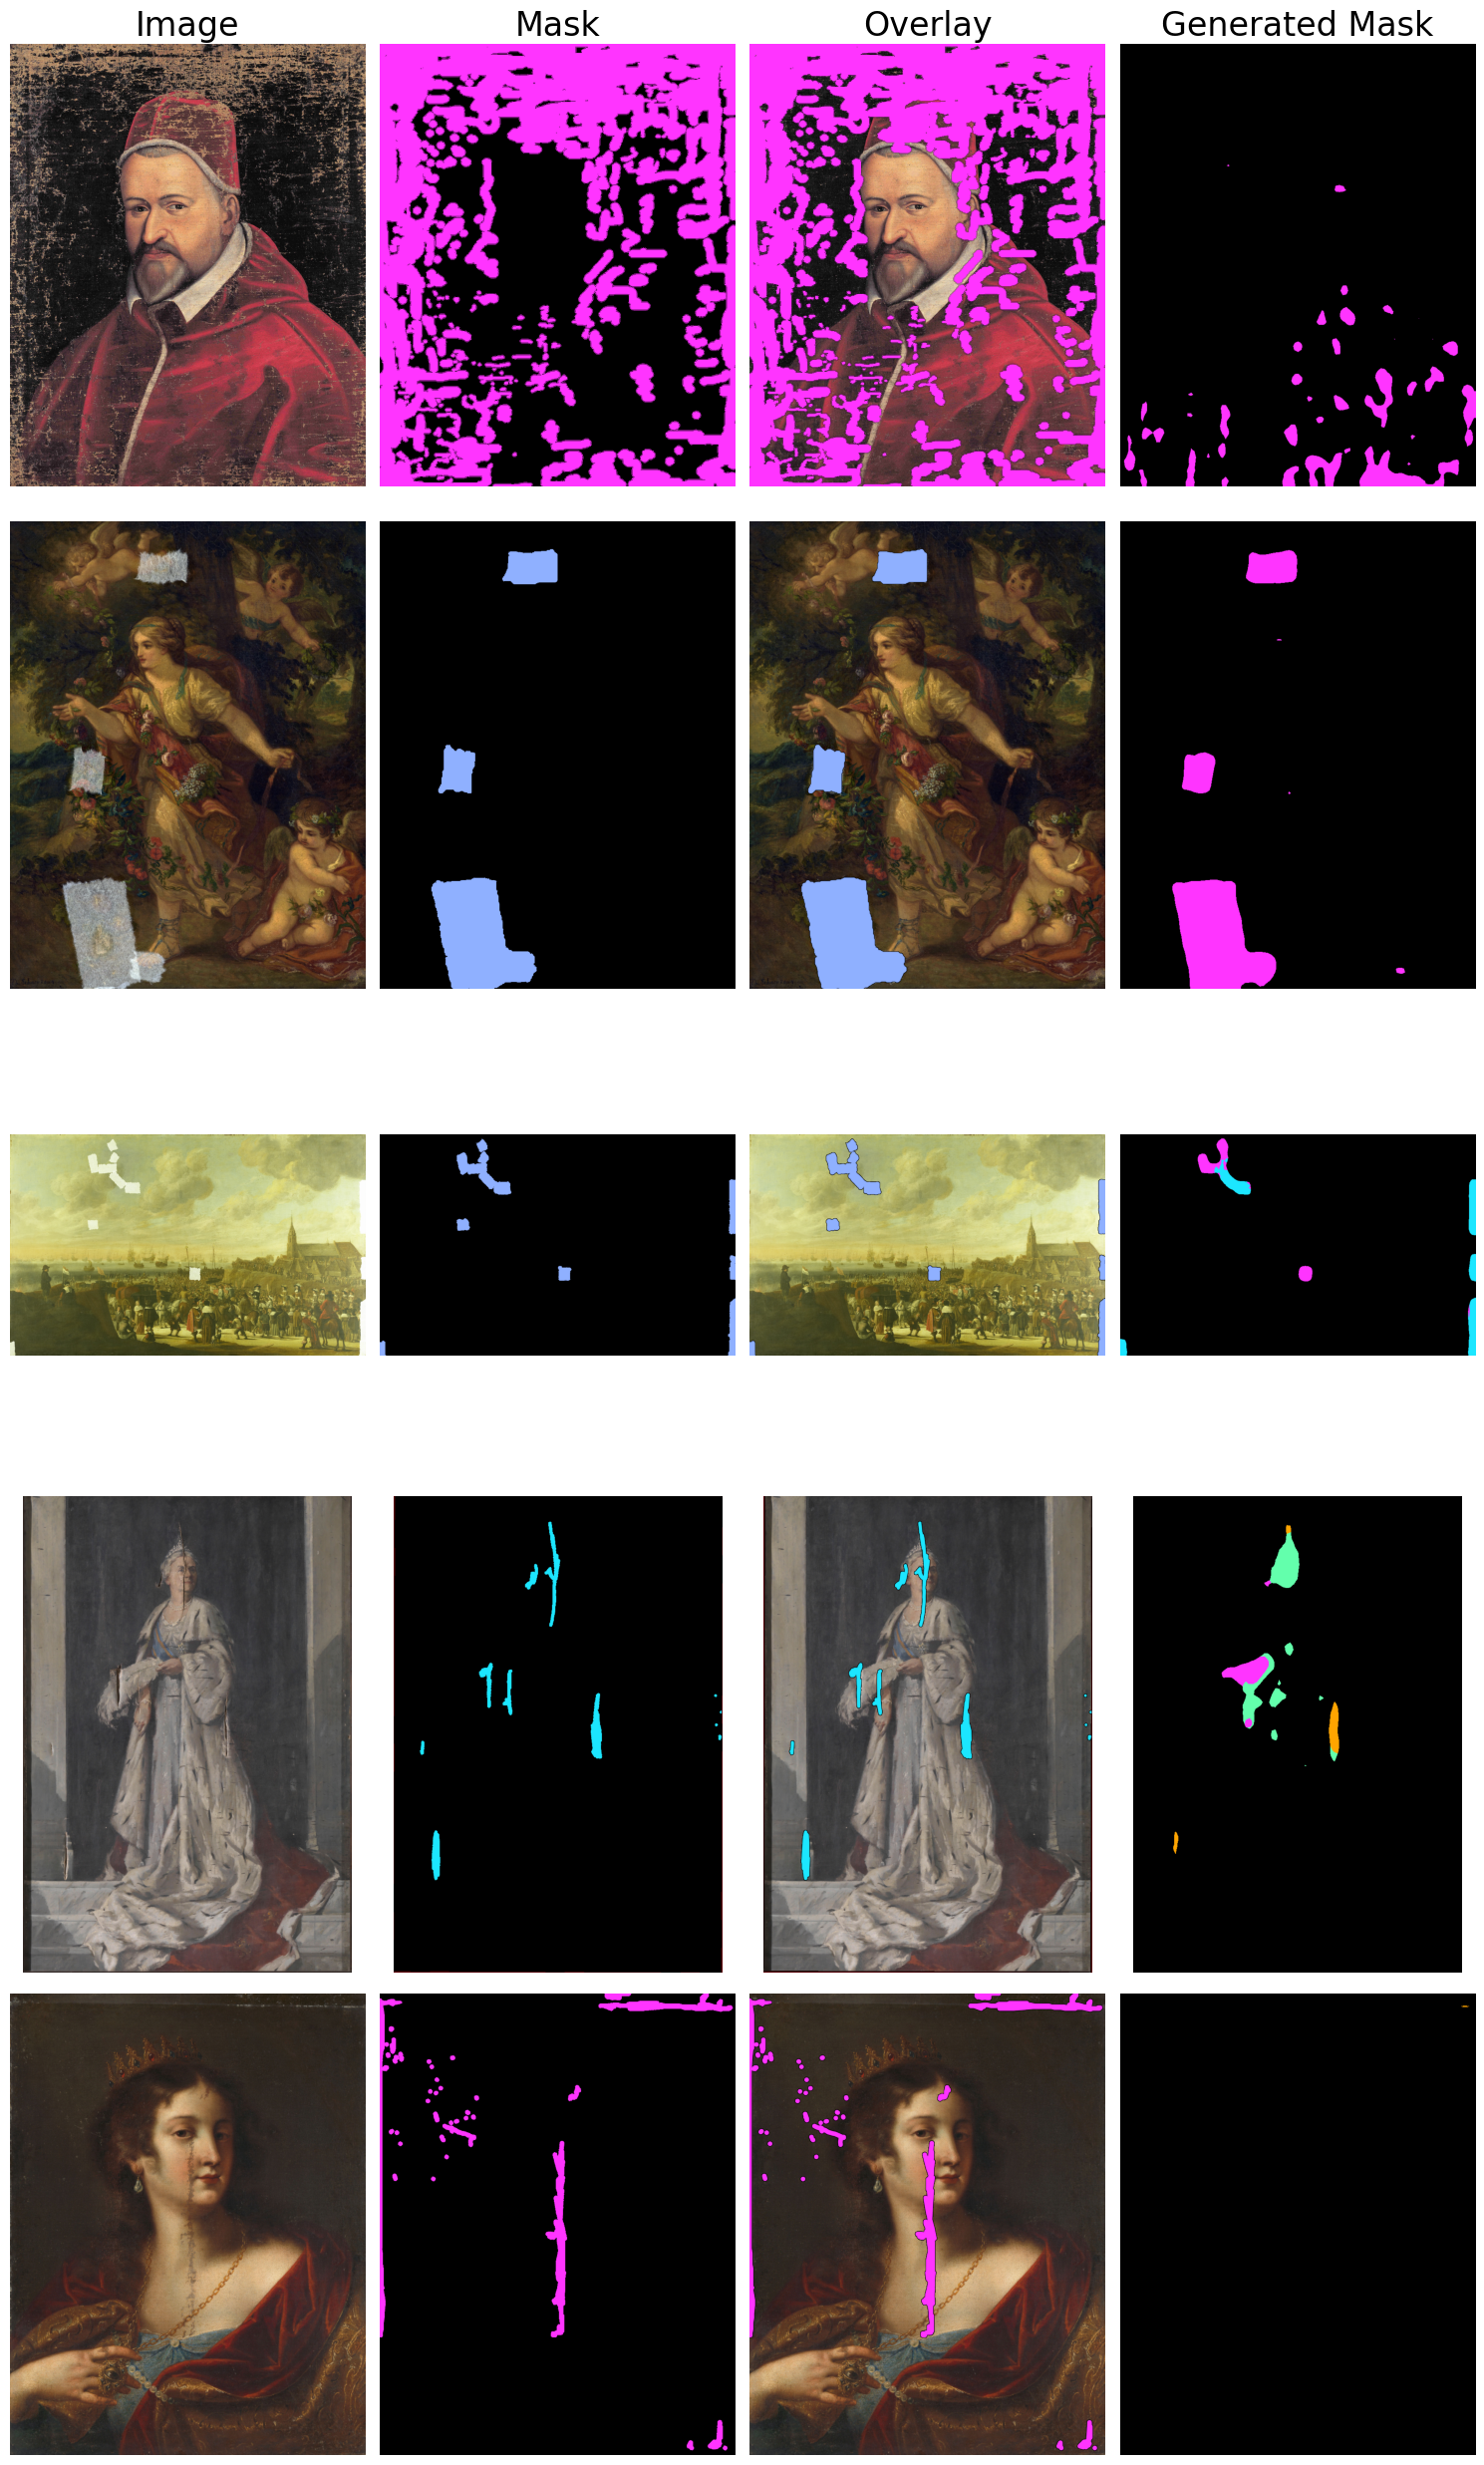

In [25]:
# Number of examples to visualize
N = 5

test_iter = iter(test_loader)
# for _ in range(8):
#   next(test_iter)
example_batches = [next(test_iter) for _ in range(N)]

# Initialize empty lists to collect different parts of each batch
example_images = []
example_annotations = []
example_annotation_rgbs = []
example_annotation_masks = []
example_generated_annotation_masks = []
example_materials = []
example_contents = []

# Populate the lists with the data from the 4 batches
for batch in example_batches:
    example_images.append(batch['image'].squeeze())
    example_annotations.append(batch['annotation'].squeeze())
    example_annotation_rgbs.append(batch['annotation_rgb'].squeeze())
    example_annotation_masks.append(batch['annotation_mask'].squeeze())
    # example_generated_annotation_masks.append(model(batch['image'].to(DEVICE)))       # Other models
    # example_generated_annotation_masks.append(model(batch['image'].to(DEVICE))['out'])  # DeepLabV3 GPU
    example_generated_annotation_masks.append(model(batch['image'])['out'])           # DeepLabV3 CPU
    example_materials.append(batch['material'][0])
    example_contents.append(batch['content'][0])

fig, axes = plt.subplots(N, 4, figsize=(15, 5 * N))

for ax, col in zip(axes[0], ['Image', 'Mask', 'Overlay', 'Generated Mask']):
    ax.set_title(col, fontsize=24)

for i in range(N):
    example_image = denormalize(example_images[i].numpy().transpose((1, 2, 0)), mean, std)  # C, H, W -> H, W, C
    example_annotation = example_annotations[i].numpy()
    example_annotation_rgb = example_annotation_rgbs[i].numpy().transpose((1, 2, 0))  # C, H, W -> H, W, C

    # Convert annotation mask to rgb image for visualisation
    example_annotation_mask = mask_to_rgb_image(example_annotation_masks[i])

    # Argmax prediction_one_hot of the generated mask
    # example_generated_annotation_mask = torch.argmax(example_generated_annotation_masks[i], dim=1).squeeze().numpy()      # Using pytorch
    example_generated_annotation_mask = np.argmax(example_generated_annotation_masks[i].detach().numpy(), axis=1).squeeze() # CPU
    # example_generated_annotation_mask = np.argmax(example_generated_annotation_masks[i].cpu().detach().numpy(), axis=1).squeeze() # GPU

    print(f"Unique Class ID: {np.unique(example_generated_annotation_mask)}")
    example_generated_annotation_mask = mask_to_rgb_image(example_generated_annotation_mask)

    example_material = example_materials[i]
    example_content = example_contents[i]
    # Create an alpha (transparency) channel where black pixels in annotation_rgb are fully transparent
    alpha_channel = np.all(example_annotation_rgb == [0, 0, 0], axis=-1)
    example_annotation_rgba = np.dstack((example_annotation_rgb, np.where(alpha_channel, 0, 1)))
    axes[i, 0].imshow(example_image)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(example_annotation_mask)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(example_image)
    axes[i, 2].imshow(example_annotation_rgba)
    axes[i, 2].axis('off')

    axes[i, 3].imshow(example_generated_annotation_mask)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()